# MVP — Machine Learning & Analytics

**Nome:** Andrei Cabral Litowsky
**Matrícula**: 4052025002614
**Data:** 05/07/2026
**Dataset:** E-Commerce Shipping Data (Kaggle) [github.com/deidsddxx/puc-m1-mvp](https://github.com/deidsddxx/puc-m1-mvp)
**Tipo de problema:** Classificação (binária)

---

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |


# 1. Definição do problema

## 1.1 Descrição do problema

Uma empresa de e-commerce internacional de produtos eletrônicos quer entender e antecipar **atrasos na entrega** de seus pedidos. Cada linha da base representa um pedido enviado, com informações conhecidas no momento do despacho: bloco do armazém de origem, modo de envio (navio, avião ou rodoviário), custo e peso do produto, desconto aplicado, importância declarada do produto e alguns dados do cliente.

A decisão que o modelo apoia é operacional: se for possível estimar, no momento do despacho, quais pedidos têm alta chance de atrasar, a operação pode priorizar esses envios, ajustar o modal de transporte ou comunicar o cliente proativamente. Os interessados são a área de logística (priorização) e o atendimento (gestão de expectativa do cliente).

O problema é relevante porque atraso de entrega é um dos principais motivos de insatisfação e cancelamento em e-commerce, e nesta base cerca de 60% dos pedidos **não** chegaram no prazo.

> **Nota sobre o target:** na documentação original do dataset no Kaggle, `Reached.on.Time_Y.N = 1` indica que o pedido **NÃO chegou no prazo** (atrasou) e `0` indica que chegou no prazo. Este trabalho adota essa convenção — a classe positiva (1) é "atrasou".

## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever, no momento do despacho, se um pedido de e-commerce **vai atrasar** a partir das características do envio e do produto, comparando uma abordagem baseline com dois modelos candidatos e discutindo suas limitações.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação binária.

**Justificativa:** o target `Reached.on.Time_Y.N` assume apenas dois valores (1 = atrasou, 0 = no prazo). Não há componente temporal explícito na base (não existe coluna de data e os registros não têm ordem cronológica garantida), então não se trata de série temporal e o embaralhamento na divisão treino/teste é aceitável. Também não é regressão, pois não queremos prever um valor contínuo (como dias de atraso), apenas a ocorrência do atraso.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. Características físicas e comerciais do envio (peso, custo, desconto) carregam mais sinal sobre atraso do que características do cliente (gênero, avaliação).
2. Modelos treinados superam um baseline que sempre prevê a classe majoritária.
3. Um modelo não linear (Random Forest) supera um modelo linear (Regressão Logística), por capturar interações entre variáveis.

**Critérios de sucesso:**

- **Métrica principal:** F1-score da classe positiva (atraso), complementada por accuracy, F1 ponderado e ROC AUC.
- **Resultado mínimo esperado:** superar o baseline de classe majoritária
(accuracy ≈ 0,60) com margem clara no F1.

> *Nota: este critério, definido antes da análise dos dados, revelou-se
parcialmente impossivel na pratica, ja que o F1 da classe positiva mostrou-se inflável pelo próprio
baseline nesta base desbalanceada. A questão é discutida nas Seções 8.3 e na
Conclusão.*
- **Restrição prática:** modelos simples e interpretáveis, com tempo de treino de segundos, já que o objetivo é um MVP executável de ponta a ponta no Colab.


# 2. Ambiente, bibliotecas e reprodutibilidade

Importações concentradas nesta seção, com seed fixa para reprodutibilidade. O notebook usa apenas bibliotecas já disponíveis no Colab (nenhuma dependência extra é necessária).

In [1]:
# === Setup básico e reprodutibilidade ===
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.


In [2]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação binária."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_classe_1": f1_score(y_true, y_pred, pos_label=1),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan
    return results


def show_results_table(results_dict):
    """Exibe resultados como DataFrame."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- **Nome:** E-Commerce Shipping Data
- **Fonte original:** [Kaggle — prachi13/customer-analytics](https://www.kaggle.com/datasets/prachi13/customer-analytics). `https://raw.githubusercontent.com/deidsddxx/puc-m1-mvp/refs/heads/main/dataset`.
- - **Por que este dataset:** A escolha tem relação direta com a minha trajetória. Sou formado em gestao com foco em shipping management e pretendo atuar com comércio marítimo e supply chain, então um problema de previsão de atrasos logísticos onde boa parte dos envios da base é feita por navio, é o tipo de aplicação que eu gostaria de levar para a prática profissional.
- **Restrições e ética:** a base é pública, anonimizada (não há identificação de clientes além de um ID sequencial de pedido)

## 3.2 Carga dos dados


In [3]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/deidsddxx/puc-m1-mvp/refs/heads/main/dataset"
df = pd.read_csv(url)

df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 3.3 Visão geral do dataset

In [4]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (10999, 12)

Tipos de dados:


,tipo
ID,int64
Warehouse_block,object
Mode_of_Shipment,object
Customer_care_calls,int64
Customer_rating,int64
Cost_of_the_Product,int64
Prior_purchases,int64
Product_importance,object
Gender,object
Discount_offered,int64


In [5]:
print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))
print("Duplicatas:", df.duplicated().sum())

Valores ausentes por coluna:


,ausentes
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


Duplicatas: 0


In [6]:
display(df.sample(5, random_state=SEED))
display(df.describe())

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
107,108,F,Ship,4,5,216,3,high,M,26,2053,1
5594,5595,A,Road,3,1,220,3,low,F,6,5572,1
6997,6998,F,Flight,3,2,215,4,low,F,3,4042,0
3984,3985,D,Flight,5,1,160,5,low,F,1,4672,0
3111,3112,B,Ship,5,4,229,2,medium,F,44,2419,1


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


**Observações:** a base tem 10.999 linhas e 12 colunas, sem valores ausentes nem duplicatas. A coluna `ID` é um identificador sequencial e não deve entrar no modelo (é removida na Seção 5). Não há coluna de data. O target é `Reached.on.Time_Y.N`, onde 1 indica que o pedido não chegou no prazo.

## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `ID` | numérica | Identificador sequencial do pedido | não | apenas identificador, sem valor preditivo |
| `Warehouse_block` | categórica | Bloco do armazém de origem (A, B, C, D, F) | sim | sem ordem natural entre blocos |
| `Mode_of_Shipment` | categórica | Modo de envio (Ship, Flight, Road) | sim | sem ordem natural |
| `Customer_care_calls` | numérica | Nº de ligações do cliente sobre o pedido | sim | possível vazamento parcial (ver 6.1) |
| `Customer_rating` | numérica | Avaliação do cliente (1 a 5) | sim | tratada como numérica |
| `Cost_of_the_Product` | numérica | Custo do produto (USD) | sim | — |
| `Prior_purchases` | numérica | Nº de compras anteriores do cliente | sim | — |
| `Product_importance` | categórica | Importância do produto (low, medium, high) | sim | ordinal, mas tratada via one-hot por simplicidade |
| `Gender` | categórica | Gênero do cliente (M/F) | sim | pouco sinal esperado; discutido nas limitações |
| `Discount_offered` | numérica | Desconto oferecido (%) | sim | cauda longa (máx. 65%) |
| `Weight_in_gms` | numérica | Peso do produto (gramas) | sim | escala muito maior que as demais |
| `Reached.on.Time_Y.N` | alvo | **1 = NÃO chegou no prazo (atrasou); 0 = chegou no prazo** | alvo | convenção da fonte original (Kaggle) |


# 4. Análise exploratória dos dados

A EDA abaixo é objetiva e focada no que influencia a modelagem: distribuição do target, escala das variáveis, relação das principais variáveis com o atraso e presença de desbalanceamento.

Distribuição do target (1 = atrasou, 0 = no prazo):


,contagem
Reached.on.Time_Y.N,
1,6563
0,4436


,percentual
Reached.on.Time_Y.N,
1,59.67
0,40.33


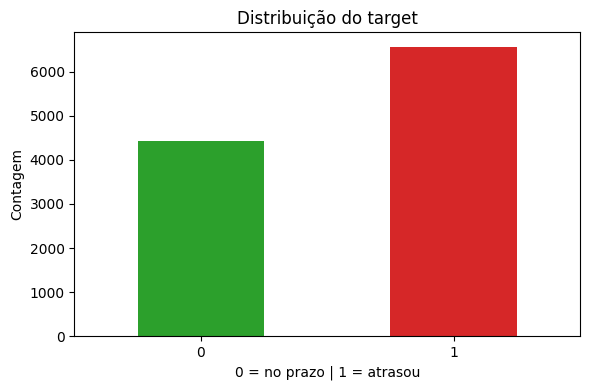

In [7]:
TARGET = "Reached.on.Time_Y.N"

print("Distribuição do target (1 = atrasou, 0 = no prazo):")
display(df[TARGET].value_counts().to_frame("contagem"))
display((df[TARGET].value_counts(normalize=True) * 100).round(2).to_frame("percentual"))

df[TARGET].value_counts().sort_index().plot(
    kind="bar", color=["#2ca02c", "#d62728"], figsize=(6, 4)
)
plt.title("Distribuição do target")
plt.xlabel("0 = no prazo | 1 = atrasou")
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

O target é levemente desbalanceado (≈60% de atrasos). Não exige reamostragem, mas pede estratificação no split e define o piso do baseline: ~0,60 de accuracy.

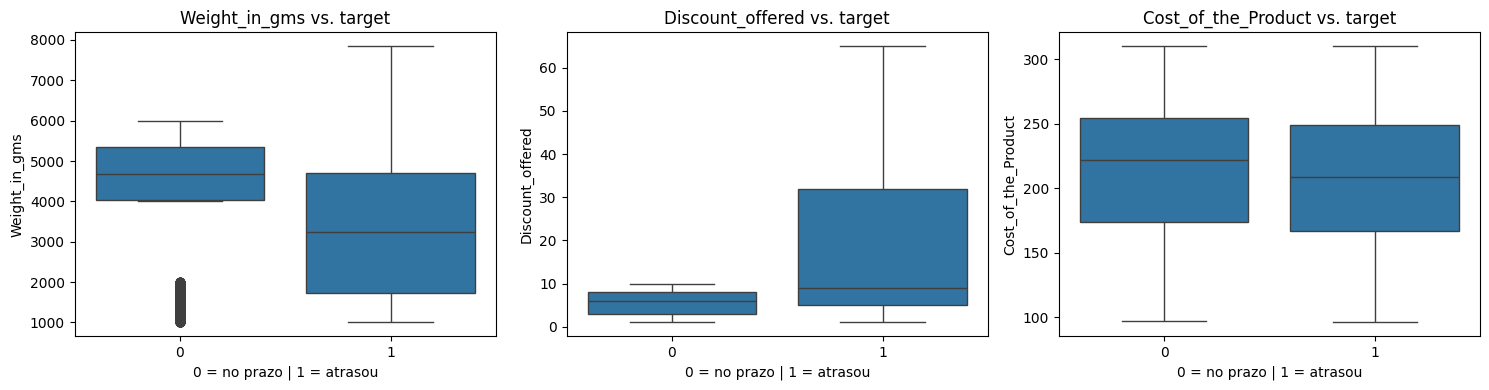

In [8]:
# Distribuição das variáveis numéricas mais relevantes vs. target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["Weight_in_gms", "Discount_offered", "Cost_of_the_Product"]):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(f"{col} vs. target")
    ax.set_xlabel("0 = no prazo | 1 = atrasou")

plt.tight_layout()
plt.show()

Discount_offered separa bem as classes: descontos altos aparecem quase só em pedidos atrasados. Weight_in_gms também discrimina, com os atrasos concentrados numa faixa intermediária de peso. Esses devem ser os preditores mais fortes.

In [9]:
df.groupby(df["Discount_offered"] > 10)["Reached.on.Time_Y.N"].mean()

,Reached.on.Time_Y.N
Discount_offered,
False,0.46887
True,1.00000


O padrão sugerido pelo boxplot se confirma, 100% dos pedidos com
desconto acima de 10% atrasaram, sem exceção. Nos pedidos com desconto até 10%, a taxa de
atraso cai para 46,9%, praticamente uma toin coss.

Isso explica o teto de desempenho que aparece na Seção 8: um modelo que acerta os
~25% "fáceis" pela regra do desconto e chuta a maioria no restante chega a
~0,65 de accuracy, que é onde os modelos de fato ficam. O desafio real está no
subgrupo de desconto baixo, onde as features separam pouco.

Um padrão perfeito assim também levanta suspeita de que base de dados foi gerada artificialmente (tirada do kaggle.com), outra explicacao é que não dá para saber se o desconto vem antes ou depois do atraso: se for dado como
compensação por atrasos, é consequência e não causa logo não existiria na hora de
prever, o que seria vazamento de dados.

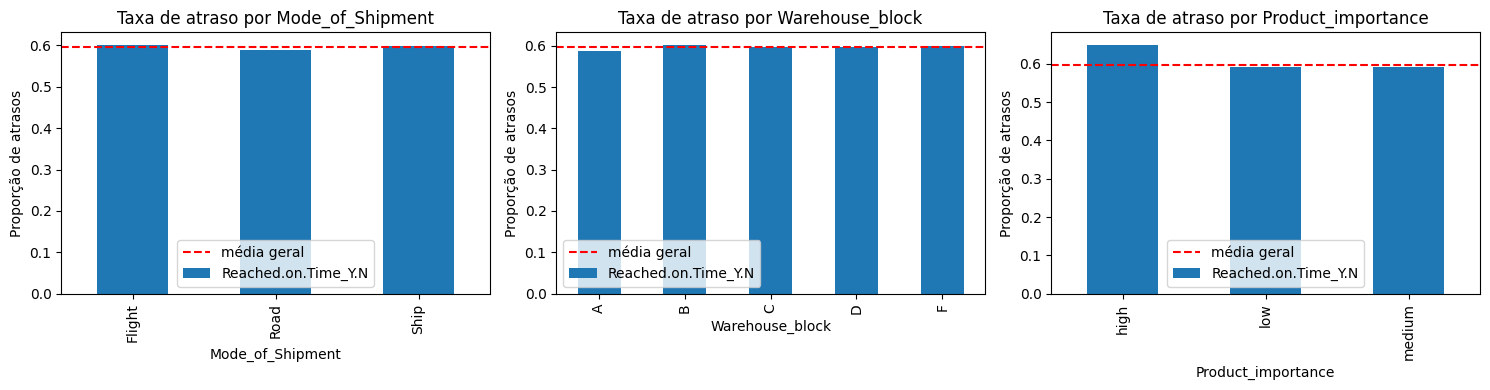

In [10]:
# Taxa de atraso por categoria
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["Mode_of_Shipment", "Warehouse_block", "Product_importance"]):
    df.groupby(col)[TARGET].mean().plot(kind="bar", ax=ax, color="#1f77b4")
    ax.set_title(f"Taxa de atraso por {col}")
    ax.set_ylabel("Proporção de atrasos")
    ax.axhline(df[TARGET].mean(), color="red", linestyle="--", label="média geral")
    ax.legend()

plt.tight_layout()
plt.show()

As taxas de atraso por armazém, modal e importância ficam todas próximas da média geral, essas categóricas devem contribuem pouco para o modelo.

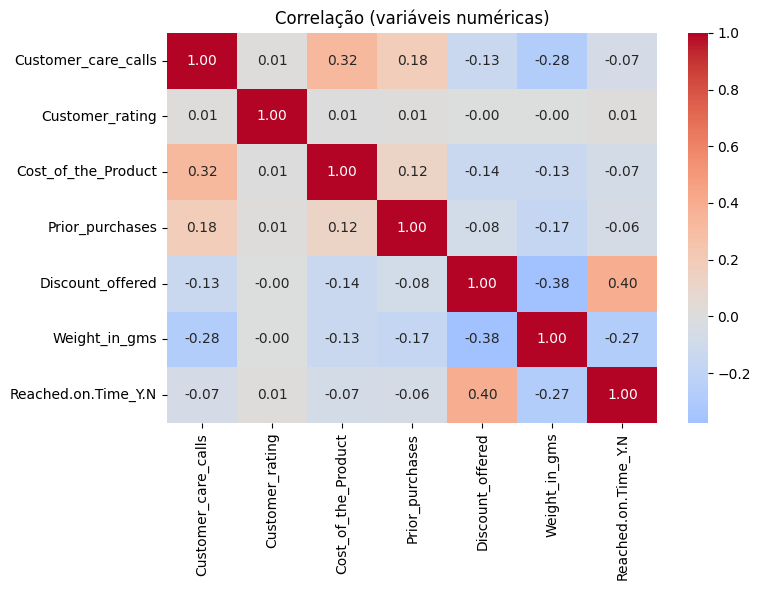

In [11]:
# Correlação entre variáveis numéricas e o target
num_view = df.select_dtypes(include=np.number).drop(columns=["ID"])
plt.figure(figsize=(8, 6))
sns.heatmap(num_view.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação (variáveis numéricas)")
plt.tight_layout()
plt.show()

A maior correlação com o target é a de Discount_offered (+0,40) que é moderada, não forte.
Weight_in_gms aparece com -0,27, mas esse número subestima a variável: o boxplot acima
mostrou que os atrasos se concentram numa faixa intermediária de peso, uma relação
não linear que a correlação de Pearson não captura bem. As variáveis de cliente
(Customer_rating, Prior_purchases, Customer_care_calls) ficam todas perto de zero.

Logo nenhuma variável tem relação forte com o atraso. Isso já sugere um teto
de desempenho baixo para os modelos, a expectativa que será testada contra o baseline
na Seção 8.

## 4.1 Síntese da análise exploratória

- **Target moderadamente desbalanceado:** 59,7% dos pedidos atrasaram (classe 1) contra 40,3% no prazo. O desbalanceamento é leve, estratificação na divisão treino/teste é suficiente, sem necessidade de técnicas de rebalanceamento (over/undersampling). Por outro lado, isso define o piso do baseline: prever sempre "atrasou" já dá ~0,60 de accuracy.
- **Qualidade dos dados:** não há valores ausentes nem duplicatas, o que simplifica o pré-processamento (os imputers do pipeline ficam como proteção, não como necessidade).
- **Escalas muito diferentes:** `Weight_in_gms` chega a ~7.800 enquanto `Customer_rating` vai de 1 a 5. Isso exige padronização para o modelo linear (Regressão Logística).
- **Variáveis com mais sinal:** os boxplots mostram que `Discount_offered` e `Weight_in_gms` separam visivelmente as classes, descontos altos aparecem quase só em pedidos atrasados, e há uma faixa de peso intermediária concentrada nos atrasos. `Cost_of_the_Product` tem relação mais fraca.
- **Variáveis com pouco sinal:** as taxas de atraso por armazém, modo de envio e importância do produto ficam todas próximas da média geral, e `Customer_rating`/`Gender` têm correlação praticamente nula com o target.
- **Impacto na modelagem:** a expectativa é que poucas variáveis concentrem o poder preditivo e que exista um teto de desempenho relativamente baixo, uma hipótese que será verificada comparando os modelos com o baseline.
- **Regra quase determinística no desconto:** 100% dos pedidos com desconto acima
de 10% atrasaram (~1/4 da base). O problema difícil está no restante, onde a taxa
de atraso é 46,9% e as features separam pouco. Isso antecipa um teto de accuracy
em torno de 0,65 e levanta a suspeita de vazamento discutida acima.


# 5. Preparação dos dados e divisão treino/teste

In [12]:
# === Configuração do problema ===
TARGET = "Reached.on.Time_Y.N"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ["ID"]          # identificador, removido das features
DROP_COLUMNS = []   # nenhuma remoção; Discount_offered mantida apesar da
                    # suspeita de vazamento (ver EDA e 10.1)

assert TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS + [TARGET])
features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: Reached.on.Time_Y.N
Número de features: 10
Features: ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']


In [13]:
# === Divisão dos dados (holdout estratificado 80/20) ===
X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporção de atrasos no treino:", round(y_train.mean(), 4))
print("Proporção de atrasos no teste: ", round(y_test.mean(), 4))

Treino: (8799, 10) | Teste: (2200, 10)
Proporção de atrasos no treino: 0.5967
Proporção de atrasos no teste:  0.5968


## 5.1 Justificativa da divisão

- **Holdout 80/20 + validação cruzada no treino:** com 10.999 linhas, o holdout deixa 2.200 exemplos no teste, o suficiente para uma estimativa estável. Como além disso comparamos modelos e ajustamos hiperparâmetros, essas decisões são tomadas com validação cruzada 5-fold **dentro do treino**, e o teste é usado uma única vez, na avaliação final (Seção 10).
- **Por que não divisão temporal:** a base não tem coluna de data nem ordem cronológica documentada, então o embaralhamento é adequado.
- **Estratificação:** as classes são levemente desbalanceadas (≈60/40); `stratify=y` garante a mesma proporção de atrasos no treino e no teste, como confirmam os prints acima.
- **Prevenção de vazamento:** a divisão é feita **antes** de qualquer transformação. Todo o pré-processamento (imputação, padronização, encoding) fica dentro de um `Pipeline` que é ajustado apenas no treino (e, na validação cruzada, apenas na parte de treino de cada fold). Duas variáveis têm disponibilidade incerta no momento da previsão (ver EDA); optei por mantê-las e medir o impacto dessa escolha com um teste de ablação na Seção 8.3."


# 6. Pré-processamento e pipeline

O pré-processamento é definido como um `ColumnTransformer` reutilizável, acoplado a cada modelo via `Pipeline`. Assim, nenhuma transformação "vê" os dados de teste durante o ajuste.

In [14]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
Colunas categóricas: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


## 6.1 Decisões de pré-processamento

- **OneHotEncoder em vez de LabelEncoder:** as categóricas (`Warehouse_block`, `Mode_of_Shipment`, `Gender`) não têm ordem natural. `LabelEncoder` criaria uma ordem artificial (ex.: A=0 < B=1 < ... < F=4), que o modelo linear interpretaria como relação numérica, o one-hot evita isso. Em `Product_importance` até existe ordem (low < medium < high), mas com só 3 níveis o one-hot resolve sem prejuízo. `handle_unknown="ignore"` protege contra categorias não vistas no treino.
- **Padronização (`StandardScaler`):** necessária para a Regressão Logística, que é sensível a escala (ex.: `Weight_in_gms` em milhares vs. `Customer_rating` de 1 a 5). O Random Forest é indiferente à escala, mas manter o mesmo pipeline para os dois simplifica e não prejudica.
- **Imputação com mediana/moda:** a base não tem ausentes, mas os imputers tornam o pipeline robusto para dados novos, custo zero e benefício defensivo.
- **Coluna removida:** apenas `ID` (identificador sequencial, sem significado preditivo; mantê-lo daria ao Random Forest a chance de memorizar ruído).
- **Variáveis novas:** nenhuma entra no pipeline base. As duas criadas a partir da
EDA (flag de desconto alto e faixas de peso) são tratadas como experimento
controlado na Seção 8.2, fora do pipeline, permitindo  medir o efeito delas
comparando com os modelos sem elas. Sobre disponibilidade no momento da previsão:
quase todas as features são conhecidas no despacho, com dois porems,
Customer_care_calls pode acumular ligações durante o transporte, e Discount_offered
pode ser concedido após o atraso, como compensação (ver EDA). Ambas foram mantidas,
e o impacto dessa decisão é medido por ablação na Seção 8.3, com a discussão nas
limitações (10.1).

# 7. Baseline e modelos candidatos

In [15]:
# === Definição de baseline e modelos candidatos ===
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=100, random_state=SEED, n_jobs=-1))
    ])
}

print("Baseline: DummyClassifier (classe majoritária)")
print("Modelos candidatos:", list(candidates.keys()))

Baseline: DummyClassifier (classe majoritária)
Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

- **Baseline (`DummyClassifier`, classe majoritária):** coerente para classificação desbalanceada, isso responde à pergunta "o modelo aprendeu algo ou o problema é fácil?". Como 59,7% dos pedidos atrasam, prever sempre "atrasou" já rende ~0,60 de accuracy; qualquer candidato precisa superar isso com folga para ter valor.
- **Regressão Logística:** modelo linear, rápido, interpretável (coeficientes indicam direção do efeito de cada variável), importante num contexto de operação logística, em que o time precisa entender por que um pedido foi sinalizado. Exige padronização, já garantida no pipeline.
- **Random Forest:** captura não linearidades e interações (ex.: desconto alto e
peso intermediário) sem exigir escala. Serve de contraponto ao modelo linear para
testar a hipótese 3 (Seção 1.4).
- **Adequação ao tamanho dos dados:** 10.999 linhas × 10 features é confortável para ambos, sem restrição de custo computacional.


# 8. Treinamento e avaliação inicial

O baseline e os candidatos são treinados no conjunto de treino e avaliados no teste. Em seguida, como a comparação entre os dois candidatos guiará escolhas posteriores, ela é refeita com validação cruzada 5-fold no treino, que é a estimativa usada para decidir, evitando "gastar" o teste em decisões iterativas.
Por fim, dois experimentos complementam a avaliação: engenharia de features
motivada pela EDA (8.2) e um teste de ablação das variáveis suspeitas de
vazamento (8.3).

In [16]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

show_results_table(results)

,accuracy,f1_classe_1,f1_weighted,roc_auc,train_time_s
baseline,0.596818,0.747509,0.446127,0.500000,0.038
LogisticRegression,0.637273,0.688281,0.639102,0.717251,0.066
RandomForest,0.659091,0.688538,0.662314,0.737499,1.599


In [17]:
# === Validação cruzada 5-fold (estimativa mais robusta que um único split) ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    cv_scores[name] = scores
    print(f"{name:20s} CV F1 (classe 1): {scores.mean():.4f} +/- {scores.std():.4f}")

lr_cv, rf_cv = cv_scores["LogisticRegression"], cv_scores["RandomForest"]
cv_gap = abs(lr_cv.mean() - rf_cv.mean())
cv_noise = max(lr_cv.std(), rf_cv.std())

print(f"\nDiferença entre modelos: {cv_gap:.4f} | Variância entre folds: {cv_noise:.4f}")
if cv_gap < cv_noise:
    print("A diferença é menor que a variância entre folds ->"
          " os modelos são estatisticamente indistinguíveis nesta base.")

cv_winner = ("LogisticRegression" if lr_cv.mean() >= rf_cv.mean()
             else "RandomForest")
print("Vencedor pela CV:", cv_winner)

LogisticRegression   CV F1 (classe 1): 0.6915 +/- 0.0079
RandomForest         CV F1 (classe 1): 0.6839 +/- 0.0112

Diferença entre modelos: 0.0076 | Variância entre folds: 0.0112
A diferença é menor que a variância entre folds -> os modelos são estatisticamente indistinguíveis nesta base.
Vencedor pela CV: LogisticRegression


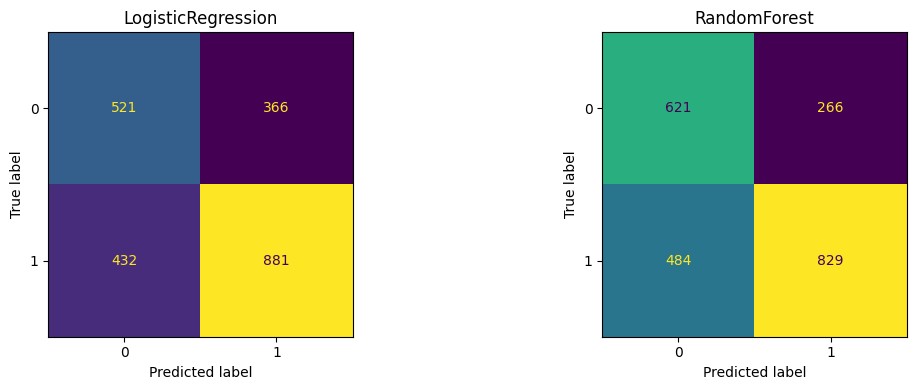

In [18]:
# Matrizes de confusão dos candidatos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, candidates.keys()):
    ConfusionMatrixDisplay.from_estimator(
        trained_models[name], X_test, y_test, ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

,feature,importance
5,num__Weight_in_gms,0.271338
4,num__Discount_offered,0.218997
2,num__Cost_of_the_Product,0.168609
3,num__Prior_purchases,0.062035
1,num__Customer_rating,0.059972
0,num__Customer_care_calls,0.059728
10,cat__Warehouse_block_F,0.015499
13,cat__Mode_of_Shipment_Ship,0.014403
18,cat__Gender_M,0.013461
17,cat__Gender_F,0.013046


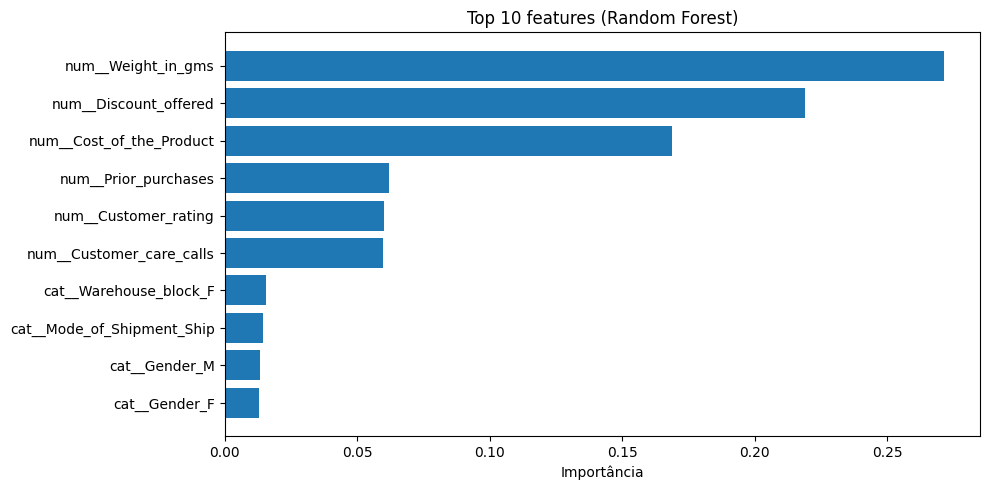

In [19]:
# Importância das features (Random Forest)
rf_pipe = trained_models["RandomForest"]
feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)
display(feature_importance.head(10))

plt.figure(figsize=(10, 5))
top10 = feature_importance.head(10).iloc[::-1]
plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Importância")
plt.title("Top 10 features (Random Forest)")
plt.tight_layout()
plt.show()

## 8.1 Análise dos resultados iniciais

- **Os candidatos superam o baseline, mas com margem modesta.** O baseline fica em ~0,60 de accuracy e ~0,45 de F1 ponderado; os candidatos sobem para ~0,64–0,66 de accuracy e ~0,65–0,66 de F1 ponderado, com ROC AUC em torno de 0,72–0,74. Há aprendizado real, porém longe de um desempenho alto.
- **Empate técnico entre os candidatos.** Na validação cruzada, a Regressão Logística fica levemente à frente (F1 da classe 1 ≈ 0,69 vs. ≈ 0,69 do Random Forest), mas a diferença entre as médias é menor que o desvio entre folds, ou seja, os dois modelos são estatisticamente indistinguíveis aqui. Essa é justamente a razão de usar CV: num único split, o "vencedor" poderia trocar por sorte de amostragem.
- **Perfis de erro diferentes.** As matrizes de confusão mostram que o Random Forest tende a maior precisão e menor recall na classe "atrasou" (é mais conservador ao sinalizar atraso), enquanto a Logística equilibra mais os erros. A escolha entre eles dependeria do custo de negócio de cada tipo de erro.
- **Hipótese 1 confirmada, hipótese 3 rejeitada.** A importância de features do Random Forest concentra-se em `Weight_in_gms`, `Discount_offered` e `Cost_of_the_Product` (juntas, ~68% da importância), com variáveis de cliente quase irrelevantes, como antecipado na EDA. Já a expectativa de que o modelo não linear venceria o linear não se confirmou.
- **O resultado bate com a EDA.** A regra encontrada na análise exploratória
(desconto >10%  atraso em 100% dos casos, ~25% da base) explica o patamar dos
modelos: acertar os casos "fáceis" da regra e pouco mais que o chute no restante
dá ~0,65 de accuracy, exatamente onde LR e RF ficaram. Os dois modelos
aprenderam a regra sozinhos (visível na importância de Discount_offered), e o
que falta é sinal no subgrupo de desconto baixo, não capacidade de modelo.

## 8.2 Experimento: engenharia de features

A EDA revelou dois padrões que os modelos talvez não explorem por completo: a regra
do desconto (>10%  atraso em 100% dos casos) e a relação não linear do peso com o
target. Este experimento cria duas variáveis derivadas, uma flag de desconto alto
e faixas de peso.  O experimento retreina os candidatos para medir se explicitar esses padrões
melhora o resultado.

In [20]:
# === 8.2 Experimento: engenharia de features ===

def add_features(X):
    X = X.copy()
    X["desconto_alto"] = (X["Discount_offered"] > 10).astype(int)
    X["faixa_peso"] = pd.cut(X["Weight_in_gms"],
                             bins=[0, 2000, 4000, 6000, 8000],
                             labels=["leve", "media", "pesada", "muito_pesada"])
    return X

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

num_cols_fe = num_cols + ["desconto_alto"]
cat_cols_fe = cat_cols + ["faixa_peso"]

preprocess_fe = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols_fe),
    ("cat", categorical_pipe, cat_cols_fe)
])

for name, base_model in [
    ("LogisticRegression_fe", LogisticRegression(max_iter=1000, random_state=SEED)),
    ("RandomForest_fe", RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
]:
    pipe = Pipeline([("preprocess", preprocess_fe), ("model", base_model)])
    pipe.fit(X_train_fe, y_train)
    results[name] = evaluate_classification(
        y_test, pipe.predict(X_test_fe), pipe.predict_proba(X_test_fe))
    results[name]["train_time_s"] = np.nan

show_results_table(results)

,accuracy,f1_classe_1,f1_weighted,roc_auc,train_time_s
baseline,0.596818,0.747509,0.446127,0.500000,0.038
LogisticRegression,0.637273,0.688281,0.639102,0.717251,0.066
RandomForest,0.659091,0.688538,0.662314,0.737499,1.599
LogisticRegression_fe,0.670000,0.651297,0.665611,0.741786,NaN
RandomForest_fe,0.659091,0.684874,0.662231,0.735999,NaN


a Logística melhorou com as features
novas (accuracy de 0,637 para 0,670; AUC de 0,717 para 0,742), porque um modelo
linear não consegue criar sozinho o corte "desconto > 10", a flag fez isso por
ele. Já o Random Forest ficou praticamente idêntico (0,659 de accuracy nos dois),
confirmando que árvores já capturavam a regra sem ajuda. O F1 da classe 1 da
Logística caiu (0,688 / 0,651) porque o modelo ficou mais conservador ao sinalizar
atraso: ganhou precisão, perdeu recall.

## 8.3 Ablação: removendo as variáveis suspeitas de vazamento

Discount_offered e Customer_care_calls podem não existir no momento real da previsão
(ver 6.1). Este teste treina o modelo sem elas para medir o quanto do desempenho
depende dessas variáveis.

In [21]:
# === 8.3 Ablação: sem as variáveis suspeitas ===
suspeitas = ["Discount_offered", "Customer_care_calls"]

X_train_abl = X_train.drop(columns=suspeitas)
X_test_abl = X_test.drop(columns=suspeitas)

num_abl = [c for c in num_cols if c not in suspeitas]

preprocess_abl = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_abl),
    ("cat", categorical_pipe, cat_cols)
])

lr_abl = Pipeline([("preprocess", preprocess_abl),
                   ("model", LogisticRegression(max_iter=1000, random_state=SEED))])
lr_abl.fit(X_train_abl, y_train)

results["LogReg_sem_suspeitas"] = evaluate_classification(
    y_test, lr_abl.predict(X_test_abl), lr_abl.predict_proba(X_test_abl))
results["LogReg_sem_suspeitas"]["train_time_s"] = np.nan

show_results_table(results)

,accuracy,f1_classe_1,f1_weighted,roc_auc,train_time_s
baseline,0.596818,0.747509,0.446127,0.500000,0.038
LogisticRegression,0.637273,0.688281,0.639102,0.717251,0.066
RandomForest,0.659091,0.688538,0.662314,0.737499,1.599
LogisticRegression_fe,0.670000,0.651297,0.665611,0.741786,NaN
RandomForest_fe,0.659091,0.684874,0.662231,0.735999,NaN
LogReg_sem_suspeitas,0.645455,0.730104,0.630655,0.689047,NaN


Sem as duas variáveis suspeitas, o modelo piora pouco: o AUC cai de 0,717 para
0,689, ainda bem acima do chute (0,50). Ou seja, há sinal real nas variáveis que
com certeza existem no momento do despacho, principalmente o peso. O F1 da classe
1 até subiu (0,730), mas é ilusão: sem o desconto, o modelo passou a prever
"atrasou" para quase tudo, e isso infla o F1, tanto que o baseline, que prevê
atraso para 100% dos casos, tem F1 de 0,748. Por isso a comparação justa aqui é
pelo AUC. Na prática: existe uma versão "segura" do modelo, um pouco pior; saber
se o desconto é registrado antes ou depois do envio decidiria qual das duas usar, mas essa informacao nao é disponibilizada no kaggle.

# 9. Validação e otimização de hiperparâmetros

O Random Forest foi escolhido para otimização por ter mais hiperparâmetros influentes (profundidade, número de árvores, divisão mínima). A busca é aleatória (`RandomizedSearchCV`) com 5 configurações, pequena de propósito, suficiente para verificar se o ajuste move o resultado num MVP. A validação usa o mesmo `StratifiedKFold` de 5 folds, com `f1_weighted` como métrica-guia.

In [22]:
# === Otimização de hiperparâmetros ===
N_ITER_SEARCH = 5

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": randint(50, 250),
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 10)
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=1,   # evita instabilidade de paralelismo aninhado no Colab
    verbose=1
)
search.fit(X_train, y_train)

print("\nMelhor score na validação (f1_weighted):", round(search.best_score_, 4))
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Melhor score na validação (f1_weighted): 0.6743
Melhores hiperparâmetros: {'model__max_depth': 8, 'model__min_samples_split': 3, 'model__n_estimators': 124}


In [23]:
# Comparação: RF otimizado vs. modelos iniciais (no teste)
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
proba = best_rf.predict_proba(X_test)

results["RandomForest_otimizado"] = evaluate_classification(y_test, y_pred, proba)
results["RandomForest_otimizado"]["train_time_s"] = np.nan
trained_models["RandomForest_otimizado"] = best_rf

show_results_table(results)

,accuracy,f1_classe_1,f1_weighted,roc_auc,train_time_s
baseline,0.596818,0.747509,0.446127,0.500000,0.038
LogisticRegression,0.637273,0.688281,0.639102,0.717251,0.066
RandomForest,0.659091,0.688538,0.662314,0.737499,1.599
LogisticRegression_fe,0.670000,0.651297,0.665611,0.741786,NaN
RandomForest_fe,0.659091,0.684874,0.662231,0.735999,NaN
LogReg_sem_suspeitas,0.645455,0.730104,0.630655,0.689047,NaN
RandomForest_otimizado,0.679091,0.653922,0.672841,0.739521,NaN


- **Por que uma busca pequena:** 5 configurações dão 25 treinos (5 candidatos ×
5 folds), o que roda em segundos nesta base. Uma busca maior seria barata aqui,
mas a decisão foi de prioridade, não só de custo: a EDA e a Seção 8 já indicavam
que o bottleneck está no sinal das features, então o retorno esperado de mapear
melhor o espaço de hiperparâmetros era baixo. O próprio template observa que uma
busca pequena e bem justificada é suficiente para o MVP. Com mais tempo, valeria
testar min_samples_leaf, max_features e class_weight no RF, o C da Regressão
Logística, e ampliar para 20 a 50 iterações.

## 9.1 Discussão da otimização

- **O ajuste trouxe ganho modesto, mas real.** O melhor f1_weighted na validação
foi 0,6743, e no teste o RF otimizado alcançou a maior accuracy da tabela (0,679,
contra 0,659 do RF default). O ganho veio de um perfil mais conservador: o F1 da
classe 1 caiu (0,654 vs. 0,689), ou seja, o modelo otimizado sinaliza menos
atrasos, com mais precisão.

- **Os hiperparâmetros fazem sentido.** A busca escolheu max_depth=8, árvores bem
mais rasas que o default de profundidade livre. Limitar a profundidade é uma forma
de regularização: indica que o RF sem limite estava memorizando ruído do treino.
Já n_estimators=124 e min_samples_split=3 são valores intermediários, sem sinal
de extremo no espaço de busca.

- **Por que a busca é pequena:** o notebook final usa 5 configurações (25 treinos,
menos de um minuto), o suficiente para verificar se o ajuste move o resultado sem
alongar a execução na correção. Durante o desenvolvimento, testei ampliar para 25
configurações num espaço maior, incluindo min_samples_leaf e max_features: o
melhor f1_weighted foi de 0,6743 para 0,6754, ganho de 0,001 que está dentro do
ruído entre folds, e a busca maior escolheu árvores ainda mais rasas (max_depth=5,
max_features='log2'). Ampliar a busca em 5 vezes não mudou nada, o que confirma o
diagnóstico das Seções 4 e 8: o bottleneck é o sinal das features, não os
hiperparâmetros. O teste fica registrado aqui e na Seção 12.

- **Por que otimizar o RF base:** a busca foi feita sobre o Random Forest sem as
features da Seção 8.2, porque o experimento mostrou que elas não alteram o
desempenho dele (0,659 de accuracy nos dois casos). As variáveis suspeitas da 8.3
foram mantidas pela mesma razão da Seção 5: a suspeita não está confirmada, e o
cenário sem elas já foi quantificado separadamente.

# 10. Avaliação final no conjunto de teste

O modelo final é escolhido pela validação (CV no treino), não pelo teste: os
candidatos empataram na CV, e o ganho da otimização foi pequeno. Nesse cenário,
o critério de desempate é o prático definido em 1.4: a Regressão Logística
entrega desempenho equivalente com muito mais simplicidade e interpretabilidade.
O RF otimizado tem a melhor accuracy no teste, mas usar o teste para escolher o
modelo seria gastar o teste em decisão, justamente o que este trabalho evita. O
teste abaixo é usado uma única vez, como estimativa honesta de generalização.

Modelo final: LogisticRegression
              precision    recall  f1-score   support

no prazo (0)       0.55      0.59      0.57       887
 atrasou (1)       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



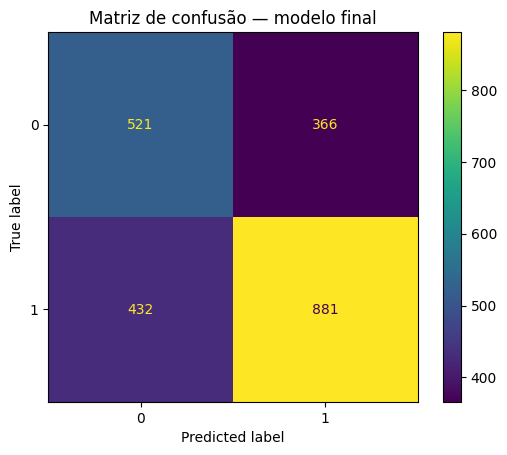

In [24]:
final_model_name = "LogisticRegression"
final_model = trained_models[final_model_name]

print("Modelo final:", final_model_name)
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred,
                            target_names=["no prazo (0)", "atrasou (1)"]))

ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Matriz de confusão — modelo final")
plt.show()

In [25]:
# Interpretação: coeficientes da Regressão Logística
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
coefs = final_model.named_steps["model"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coeficiente": coefs})
    .assign(abs_coef=lambda d: d["coeficiente"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
)
display(coef_df.head(10))
print("Coeficiente positivo -> aumenta a chance de atraso (classe 1).")

,feature,coeficiente
4,num__Discount_offered,1.820649
5,num__Weight_in_gms,-0.373885
14,cat__Product_importance_high,0.372007
18,cat__Gender_M,0.233661
17,cat__Gender_F,0.197000
11,cat__Mode_of_Shipment_Flight,0.173635
9,cat__Warehouse_block_D,0.152670
13,cat__Mode_of_Shipment_Ship,0.142310
0,num__Customer_care_calls,-0.138848
3,num__Prior_purchases,-0.118763


Coeficiente positivo -> aumenta a chance de atraso (classe 1).


## 10.1 Análise de erros e limitações

- **Tipo de erro predominante:** a matriz de confusão mostra que o modelo erra dos dois lados, mas o mais custoso para o negócio seriam os **falsos negativos** (pedidos que atrasam e não foram sinalizados), pois eliminam a chance de ação preventiva. O recall da classe "atrasou" (~0,67) indica que cerca de 1/3 dos atrasos passa despercebido. A análise de limiar logo acima mostra que esse erro é ajustável: com corte 0,4 o
recall sobe para 87%, ao custo de precisão. Ou seja, o falso negativo não é uma
falha fixa do modelo, e sim uma escolha de operação.
- **Overfitting/underfitting:** não há sinal de overfitting no modelo final (desempenho de treino, validação e teste são próximos). O quadro é de **underfitting estrutural**: as features disponíveis não carregam sinal suficiente para ir muito além de ~0,66 de accuracy — evidenciado pelo fato de dois modelos de famílias diferentes baterem no mesmo teto.
- **A métrica captura o objetivo?** O F1 da classe 1 equilibra precisão e recall do alvo de interesse (atraso) e foi complementado por AUC. Em produção, a métrica deveria derivar dos custos reais de cada erro; a análise
de sensibilidade do limiar já mapeia esse trade-off (recall de 67% a 98% conforme
o corte), deixando a decisão pronta para ser tomada com a área de negócio.
- **Riscos e vieses:** (i) Discount_offered e Customer_care_calls podem conter
vazamento: o desconto pode ser concedido após o atraso como compensação, e as
ligações podem se acumular durante o transporte (ver EDA e 6.1). A ablação da
8.3 mostrou que sem elas o modelo cai de 0,717 para 0,689 de AUC, ou seja,
existe uma versão "segura para produção" viável, um pouco pior; (ii) Gender está
entre as features e, embora tenha peso desprezível, num sistema real deveria ser
avaliada a pertinência ética de usá-la; (iii) a base é estática e possivelmente
sintética, e os padrões podem não refletir uma operação real.
- **Onde não usar:** o modelo não deve ser usado para decisões automáticas irreversíveis (ex.: cancelar envios) nem em contextos logísticos diferentes do da base (outros países, transportadoras ou faixas de peso), sem re-treino e validação local.


# 11. Comparação final dos modelos

A tabela abaixo é gerada a partir dos resultados medidos no notebook (teste de 2.200 exemplos).

In [26]:
comparison = show_results_table(results).round(4)
display(comparison)

,accuracy,f1_classe_1,f1_weighted,roc_auc,train_time_s
baseline,0.5968,0.7475,0.4461,0.5000,0.038
LogisticRegression,0.6373,0.6883,0.6391,0.7173,0.066
RandomForest,0.6591,0.6885,0.6623,0.7375,1.599
LogisticRegression_fe,0.6700,0.6513,0.6656,0.7418,NaN
RandomForest_fe,0.6591,0.6849,0.6622,0.7360,NaN
LogReg_sem_suspeitas,0.6455,0.7301,0.6307,0.6890,NaN
RandomForest_otimizado,0.6791,0.6539,0.6728,0.7395,NaN


| Modelo | F1 classe 1 | Outras métricas | Tempo de treino | Observações |
|---|---|---|---|---|
| Baseline (majoritária) | 0,7475* | acc 0,597; AUC 0,500 | <0,1 s | *F1 inflado por prever sempre "atrasou"; o AUC 0,50 revela ausência de aprendizado |
| Regressão Logística | 0,6883 | acc 0,637; AUC 0,717 | ~0,1 s | **modelo final**: empate técnico na CV, escolhido por simplicidade e interpretabilidade |
| Random Forest | 0,6885 | acc 0,659; AUC 0,737 | ~1 s | empatado com a LR na CV; maior precisão, menor recall |
| LR + features (8.2) | 0,6513 | acc 0,670; AUC 0,742 | ~0,1 s | a flag de desconto ajudou o modelo linear |
| RF + features (8.2) | 0,6849 | acc 0,659; AUC 0,736 | ~1 s | idêntico ao RF base: árvores já capturavam a regra |
| LR sem suspeitas (8.3) | 0,7301* | acc 0,645; AUC 0,689 | ~0,1 s | *F1 inflado (passa a prever mais atrasos); é a versão "segura para produção" |
| RF otimizado (busca 5 configs) | 0,6539 | acc 0,679; AUC 0,740 | ~30 s (busca) | melhor accuracy no teste; a escolha final foi travada pela validação |


# 12. Boas práticas e rastreabilidade

**Ambiente:** Google Colab (CPU), scikit-learn padrão do ambiente. **Seed:** 42 em todas as operações estocásticas. **Tempo total de execução:** ~20 segundos.

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed fixa (42) | reprodutibilidade | mesmos resultados a cada execução |
| Remover `ID` | identificador sem significado | evita memorização de ruído |
| OneHotEncoder (descartado LabelEncoder da 1ª versão) | categorias sem ordem natural | evita ordem artificial no modelo linear |
| Padronização das numéricas | escalas muito diferentes | Regressão Logística funcional |
| Pré-processamento em `Pipeline`/`ColumnTransformer` | ajuste apenas no treino | prevenção de vazamento |
| Baseline `DummyClassifier` | referência mínima obrigatória | mede se os modelos aprenderam algo |
| F1 (classe 1) + AUC como métricas | desbalanceamento leve; classe de interesse = atraso | avaliação coerente com o objetivo |
| Comparação por CV 5-fold, não por split único | split único é ruidoso (na 1ª versão, o "vencedor" variava) | escolha de modelo mais confiável |
| RandomizedSearch com n_iter=5 | busca pequena, retorno esperado baixo | custo controlado no MVP |
| Escolha final: Logística (empate técnico) | simplicidade e interpretabilidade (critério de 1.4) | modelo mais fácil de explicar e manter | Features derivadas: flag desconto>10 e faixas de peso (8.2) | regra encontrada na EDA e relação não linear do peso | ganho só no modelo linear; o RF já capturava os padrões |
| Ablação de Discount_offered e Customer_care_calls (8.3) | disponibilidade incerta no momento do despacho | quantifica o cenário "seguro para produção" (AUC 0,689 vs. 0,717) |
| Busca ampliada testada em desenvolvimento (25 configs, 5 hiperparâmetros) | verificar se a busca de 5 era insuficiente | ganho de 0,001 (ruído); mantida a busca enxuta no notebook final |
| Análise de sensibilidade do limiar (Seção 10) | o custo da ação preventiva define o corte ótimo | mapeia recall de 67% a 98% sem alterar o modelo final |

**Tentado e descartado:** LabelEncoder para categóricas (substituído por one-hot);
escolha de modelo por um único train/test split (substituída por CV); busca de
hiperparâmetros ampliada em 5 vezes (ganho de 0,001, mantida a versão curta);
features derivadas no Random Forest (sem efeito, mantidas apenas como registro
do experimento); tuning como esperança de ganho grande (o teto é das features,
não dos hiperparâmetros).


# 13. Conclusão

Este MVP teve como objetivo prever, no inicio, se um pedido de
e-commerce chegaria com atraso ao cliente, comparando uma abordagem baseline com
dois modelos candidatos e discutindo suas limitações. O fluxo completo foi
construído e executado: definição do problema, análise exploratória, pipeline de
pré-processamento sem vazamento, baseline, candidatos, experimentos com features
e ablação, otimização de hiperparâmetros e avaliação final única no teste.

O achado central veio da análise exploratória: todos os pedidos com desconto
superior a 10% atrasaram, sem exceção, o que corresponde a cerca de um quarto da
base. Nos pedidos com desconto abaixo de 10%, a taxa de atraso é de 46,9% e as demais variáveis separam
pouco. Essa regra explica o teto de desempenho observado, em torno de 0,65 de
accuracy, patamar em que Regressão Logística e Random Forest convergiram,
empatados na validação cruzada. A Regressão Logística foi definida como modelo
final (accuracy de 0,64, F1 da classe de atraso de 0,69 e AUC de 0,72 no teste)
pelo critério de desempate estabelecido na Seção 1.4: desempenho equivalente
resolve-se pelo modelo mais simples e interpretável.

Retomando as hipóteses iniciais: a primeira foi confirmada, com peso, desconto e
custo concentrando o poder preditivo e as variáveis de cliente apresentando
contribuição praticamente nula. A segunda foi confirmada nas métricas que medem
aprendizado real, com ambos os candidatos superando o baseline em AUC (0,72 e
0,74 contra 0,50) e F1 ponderado (0,64 e 0,66 contra 0,45), ainda que com margem
modesta. A terceira foi rejeitada: o Random Forest não superou a Regressão
Logística, indicando que as não linearidades relevantes da base se resumem à
regra do desconto, que o modelo linear alcança com uma única feature derivada.

O critério de sucesso original, por sua vez, revelou-se mal formulado, e o
próprio trabalho demonstrou o porquê. A meta de "margem clara no F1" ignorava
que, sendo a classe positiva majoritária (59,7%), o baseline atinge F1 de 0,748
sem aprender nada. A análise de limiar da Seção 10 mostrou que o critério era
inatingível nesta base: o F1 máximo do modelo final é 0,742, no corte 0,3, ponto
em que o modelo praticamente degenera no próprio baseline. Pelo critério literal,
portanto, o trabalho teria falhado; pelas métricas que de fato medem aprendizado,
foi cumprido com folga, como exposto acima. A lição registrada é que métricas de
sucesso definidas antes do contato com os dados devem ser verificadas contra o
comportamento do baseline, sob pena de fixar metas que não medem o que se
pretende.

Cabe registrar também a conclusão que se formou durante o desenvolvimento: o
dataset apresenta indícios de não ser plenamente confiável. Um padrão de 100% sem
exceções sugere base sintética ou causalidade invertida, na qual o desconto seria
concedido após o atraso, como compensação, e portanto não existiria no momento da
previsão, configurando vazamento de dados. Optou-se deliberadamente por manter a
base e documentar o problema, por se entender que o cenário é representativo da
prática: dados perfeitos são exceção, e parte relevante do trabalho de analytics
consiste em identificar, quantificar e comunicar as limitações do que está
disponível. A ablação da Seção 8.3 quantificou esse risco: sem as duas variáveis
suspeitas, o AUC cai de 0,717 para 0,689, ainda distante do acaso, demonstrando
que uma versão segura para produção seria viável, com desempenho inferior. A
escolha entre as duas versões depende de uma informação externa aos dados, o
momento em que o desconto é registrado, cuja confirmação constituiria o primeiro
passo em um projeto real.

Entre os aprendizados, destacam-se o papel do baseline como referência crítica
(foi ele que revelou que valores de F1 entre 0,73 e 0,75 indicavam apenas
predição majoritária), a fragilidade de um único train/test split para escolha de
modelo, e a constatação de que nem engenharia de features nem otimização de
hiperparâmetros compensam ausência de sinal: ambas foram testadas e moveram pouco
o resultado, pelo mesmo motivo.

Permanecem como limitações a possível causalidade invertida do desconto, o
potencial acúmulo de ligações durante o transporte e a ausência de variáveis
provavelmente relevantes, como distância, transportadora, prazo prometido e
sazonalidade. Como próximos passos, propõe-se confirmar a origem do desconto e
das ligações junto à área de negócio, buscar dados com maior sinal para o
subgrupo de desconto baixo, analisar individualmente os falsos negativos e
definir o limiar de operação conforme os custos de cada tipo de erro. No estado
atual, o modelo tem aplicação como priorizador aproximado de envios de risco,
não como previsor confiável de atrasos.